# EDA con visualización de datos
Gráficos de dispersión, barras y línea; ingeniería de variables (One-Hot) y generación de `dataset_part_3.csv`.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
try:
    df=pd.read_csv('dataset_part_2.csv')
except FileNotFoundError:
    df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/dataset_part_2.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


**Número de vuelo vs carga útil** (color = resultado).

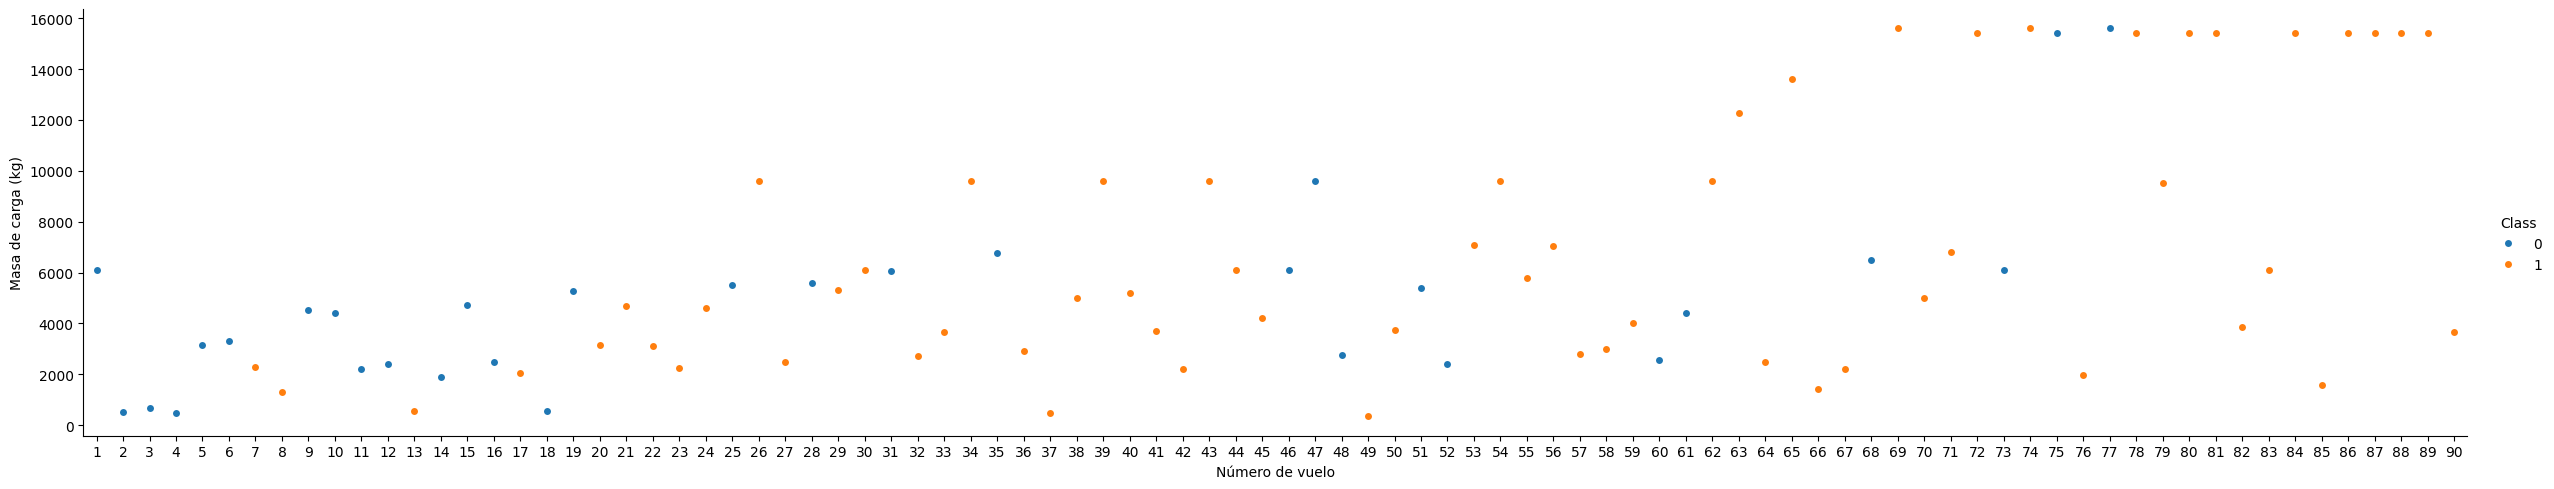

In [2]:
sns.catplot(y='PayloadMass',x='FlightNumber',hue='Class',data=df,aspect=5)
plt.xlabel('Número de vuelo');plt.ylabel('Masa de carga (kg)');plt.show()

**Número de vuelo vs sitio de lanzamiento.**

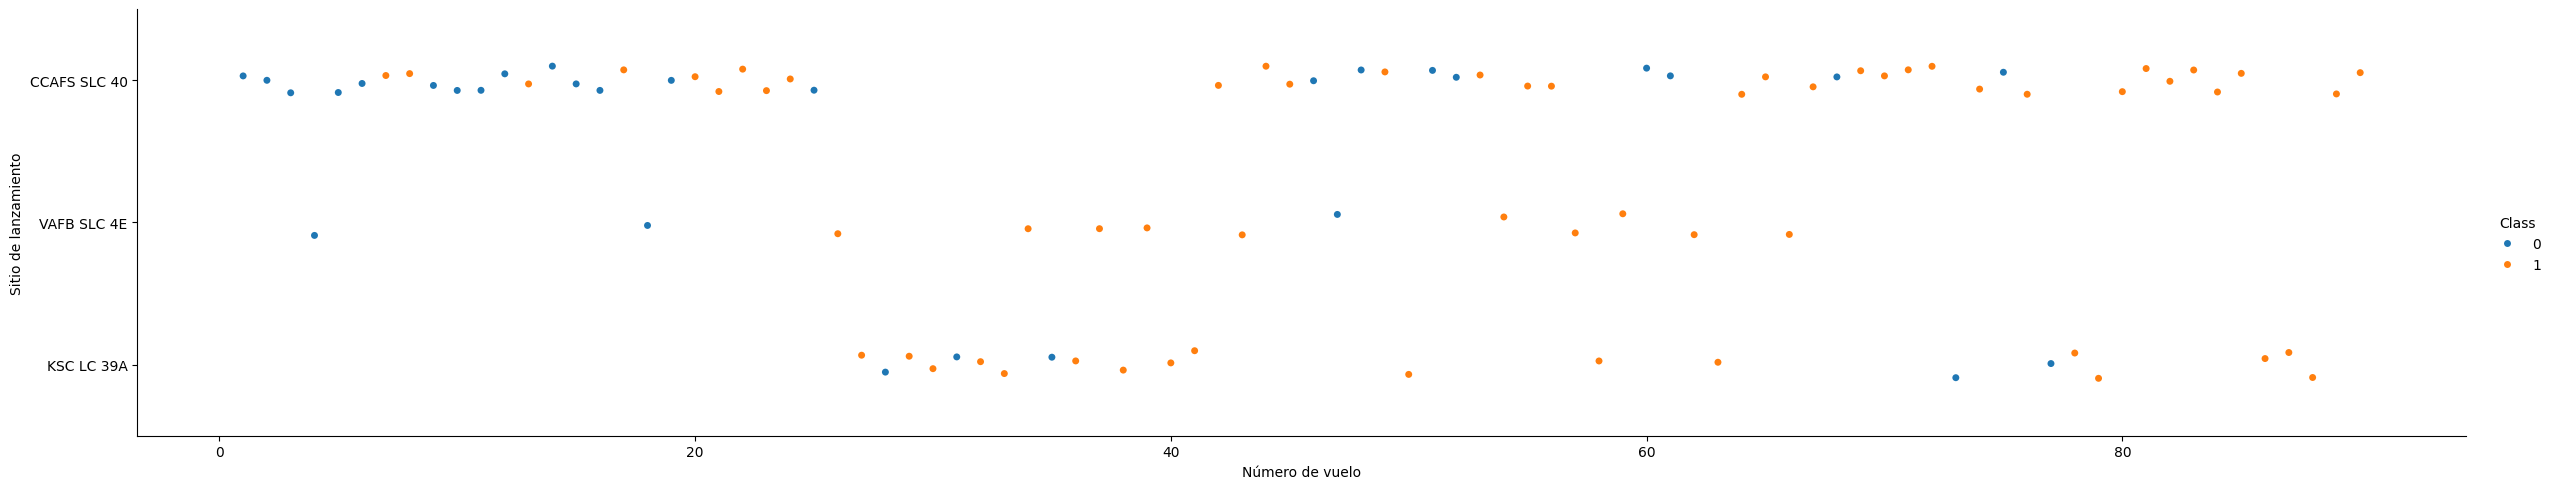

In [3]:
sns.catplot(y='LaunchSite',x='FlightNumber',hue='Class',data=df,aspect=5)
plt.xlabel('Número de vuelo');plt.ylabel('Sitio de lanzamiento');plt.show()

**Carga útil vs sitio de lanzamiento.**

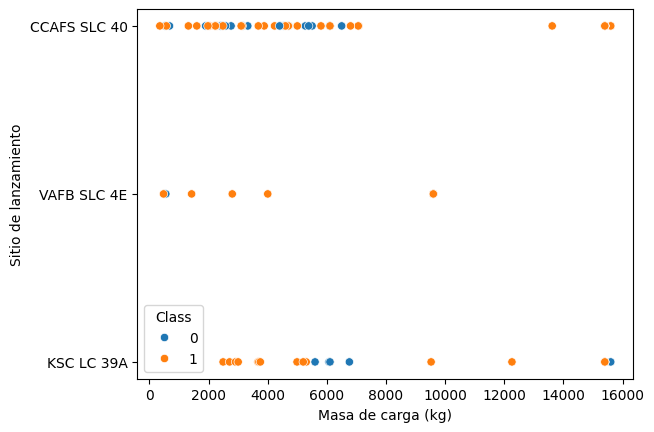

In [4]:
sns.scatterplot(y='LaunchSite',x='PayloadMass',hue='Class',data=df)
plt.xlabel('Masa de carga (kg)');plt.ylabel('Sitio de lanzamiento');plt.show()

**Tasa de éxito por órbita (barras).**

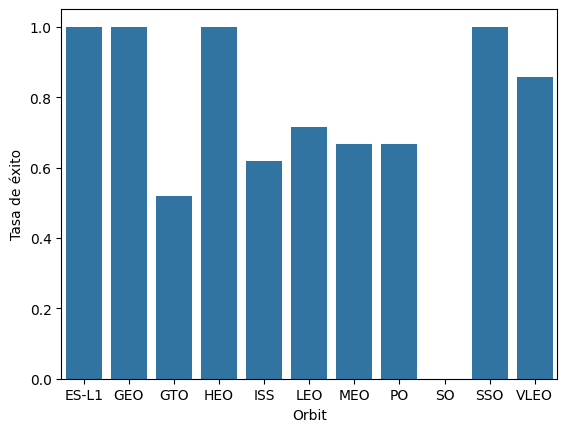

In [5]:
orb=df.groupby('Orbit')['Class'].mean().reset_index()
sns.barplot(x='Orbit',y='Class',data=orb)
plt.ylabel('Tasa de éxito');plt.show()

**Número de vuelo vs órbita y carga útil vs órbita.**

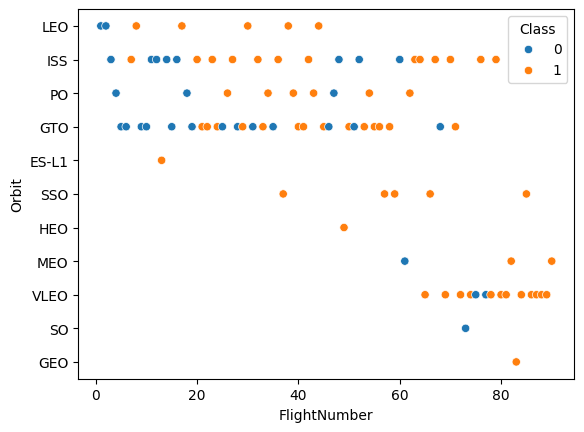

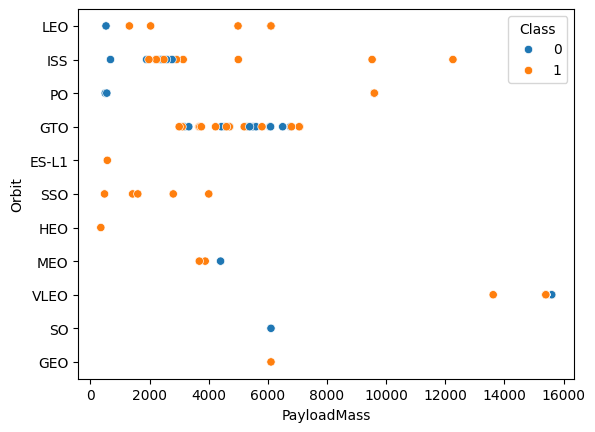

In [6]:
sns.scatterplot(y='Orbit',x='FlightNumber',hue='Class',data=df);plt.show()
sns.scatterplot(y='Orbit',x='PayloadMass',hue='Class',data=df);plt.show()

**Tendencia anual de la tasa de éxito (línea).**

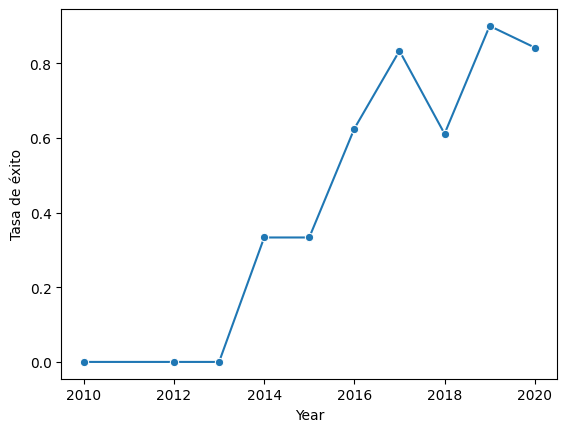

In [7]:
df['Year']=pd.to_datetime(df['Date']).dt.year
yr=df.groupby('Year')['Class'].mean().reset_index()
sns.lineplot(x='Year',y='Class',data=yr,marker='o')
plt.ylabel('Tasa de éxito');plt.show()

**Ingeniería de variables: One-Hot Encoding.**

In [8]:
features=df[['FlightNumber','PayloadMass','Orbit','LaunchSite','Flights','GridFins','Reused','Legs','LandingPad','Block','ReusedCount','Serial']]
features_one_hot=pd.get_dummies(features,columns=['Orbit','LaunchSite','LandingPad','Serial'])
features_one_hot=features_one_hot.astype('float64')
features_one_hot.to_csv('dataset_part_3.csv',index=False)
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
